In [ ]:
# Import all functions from the required modules
from cordo_sherpa_module import *
from cordo_chimere_module import *
from expo_functions_module import *
from mortality_analysis_module import *
from association_module import *
from morbidity_analysis_module import *
print("Successfully loaded all modules")

In [ ]:
# Paths to the files
path_fichier_shp = "data/2-output-data/donnees_shp"
title_shp = "donnees_insee_iris"
path_fichier_pourcents = "data/2-output-data"
title_pourcents = "pourcents"

# Load the concentration points
conc_points = coordo_sherpa(sc="s1", pol="ug_NO2", year=2019)

# Load the exported data
donnees_exportees = gpd.read_file(os.path.join(path_fichier_shp, f"{title_shp}.shp"))

# Transform the CRS of the exported data to match the concentration points
donnees_exportees_transformed = donnees_exportees.to_crs(epsg=conc_points.crs.to_epsg())

# Check if CRSs are the same
if conc_points.crs == donnees_exportees_transformed.crs:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are the same.")
else:
    print("CRS for conc_points_transformed and donnees_exportees_transformed are different.")

In [ ]:
import os
# Define paths for shapefiles
path_fichier_shp = "data/2-output-data/donnees_shp"
path_fichier_shp_1 = "data/2-output-data/donnees_shp_1"
path_fichier_shp_2 = "data/2-output-data/donnees_shp_2"
path_fichier_shp_3 = "data/2-output-data/donnees_shp_3"
path_fichier_pourcents = "data/2-output-data"

# Titles for INSEE Data
title_shp = "donnees_insee_iris"
title_shp_1 = "donnees_insee_iris_toutage_1"
title_shp_2 = "donnees_insee_iris_toutage_2"
title_shp_3 = "donnees_insee_iris_toutage_3"
title_pourcents = "pourcents"

# Read shapefiles into GeoDataFrames
donnees_shp_1 = gpd.read_file(os.path.join(path_fichier_shp_1, f"{title_shp_1}.shp"))
donnees_shp_2 = gpd.read_file(os.path.join(path_fichier_shp_2, f"{title_shp_2}.shp"))
donnees_shp_3 = gpd.read_file(os.path.join(path_fichier_shp_3, f"{title_shp_3}.shp"))

# Combine the three GeoDataFrames
donnees_merged = gpd.GeoDataFrame(pd.concat([donnees_shp_1, donnees_shp_2, donnees_shp_3], ignore_index=True))
print(donnees_merged.head())

grille_combinee = gpd.read_file(os.path.join(path_fichier_pourcents, f"{title_pourcents}.shp"))
grille_combinee = grille_combinee.to_crs(conc_points.crs)

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# File paths
density_data_path = "data/1-processed-data/grille_densite_7_niveaux_2019.xlsx"
commune_shp_path = "data/1-processed-data/CONTOURS-COMM/COMMUNE.shp"

# Read the density classification data
print("Reading density data...")
density_data = pd.read_excel(density_data_path)

# Format CODGEO for consistency
density_data["CODGEO"] = density_data["CODGEO"].astype(str).str.zfill(5).str.strip()

# Read the commune shapefile
print("Reading commune shapefile...")
commune_gdf = gpd.read_file(commune_shp_path)
commune_gdf["INSEE_COM"] = commune_gdf["INSEE_COM"].astype(str).str.zfill(5).str.strip()

# Repair geometries in the shapefile
commune_gdf["geometry"] = commune_gdf["geometry"].buffer(0)

# Merge density data with commune shapefile
print("Merging density data with commune geometries...")
merged_gdf = commune_gdf.merge(
    density_data[["CODGEO", "LIBDENS", "DENS"]],
    left_on="INSEE_COM",
    right_on="CODGEO",
    how="left"
)

# Align CRS with commune shapefile (ensure Lambert-93 for France)
merged_gdf = merged_gdf.to_crs(epsg=2154)

# Handle missing values and ensure LIBDENS is used for ordered plotting
merged_gdf["LIBDENS"] = merged_gdf["LIBDENS"].fillna("Non classé")
merged_gdf["DENS"] = merged_gdf["DENS"].fillna(8)  # Assign a high number for unclassified

# Sort by DENS to ensure LIBDENS legend categories are logically ordered (Urban to Rural)
merged_gdf = merged_gdf.sort_values("DENS")

# Debugging information
unmatched_rows = merged_gdf[merged_gdf["CODGEO"].isna()]
print(f"Unmatched rows count: {len(unmatched_rows)}")

# Plotting the map using LIBDENS categories
print("Plotting density map based on LIBDENS...")
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

# Map LIBDENS with a sequential colormap to simulate a "continuous" spatial distribution
merged_gdf.plot(
    column="LIBDENS",
    ax=ax,
    legend=True,
    categorical=True,
    cmap="Spectral",
    legend_kwds={'title': "Density Classification", 'bbox_to_anchor': (1, 1), 'loc': 'upper left'},
    edgecolor='none'
)

ax.set_title("Spatial Distribution of French Communes by Density (LIBDENS)", fontsize=16)
ax.axis("off")

# Save map as image
output_map_path = "data/2-output-data/density_classification_libdens_map.png"
plt.savefig(output_map_path, dpi=300, bbox_inches="tight")
print(f"Map saved to {output_map_path}")

plt.show()


In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# File paths
density_data_path = "data/1-processed-data/grille_densite_7_niveaux_2019.xlsx"
commune_shp_path = "data/1-processed-data/CONTOURS-COMM/COMMUNE.shp"

# Read the density classification data
print("Reading density data...")
density_data = pd.read_excel(density_data_path)

# Format CODGEO for consistency
density_data["CODGEO"] = density_data["CODGEO"].astype(str).str.zfill(5).str.strip()

# Function: Create `area_cluster` from `DENS`
def dens_to_cluster(row):
    dens = row["DENS"]
    if dens in [1, 2]:  # Urban Dense
        return "Urban"
    elif dens in [3, 4]:  # Semi-Urban
        return "Semi-Urban"
    elif dens in [5, 6, 7]:  # Rural
        return "Rural"
    return "Unknown"

# Apply the clustering logic
density_data["area_cluster"] = density_data.apply(dens_to_cluster, axis=1)

# Read the commune shapefile
print("Reading commune shapefile...")
commune_gdf = gpd.read_file(commune_shp_path)
commune_gdf["INSEE_COM"] = commune_gdf["INSEE_COM"].astype(str).str.zfill(5).str.strip()

# Repair geometries in the shapefile
commune_gdf["geometry"] = commune_gdf["geometry"].buffer(0)

# Merge density data with commune shapefile
print("Merging density data with commune geometries...")
merged_gdf = commune_gdf.merge(
    density_data[["CODGEO", "area_cluster", "DENS"]],
    left_on="INSEE_COM",
    right_on="CODGEO",
    how="left"
)

# Align CRS with commune shapefile (ensure Lambert-93 for France)
merged_gdf = merged_gdf.to_crs(epsg=2154)

# Handle missing values and ensure area_cluster is used for ordered plotting
merged_gdf["area_cluster"] = merged_gdf["area_cluster"].fillna("Unknown")
merged_gdf["DENS"] = merged_gdf["DENS"].fillna(8)  # Assign a high number for unclassified

# Sort by DENS to ensure area_cluster legend categories are logically ordered (Urban to Rural)
cluster_order = {"Urban": 1, "Semi-Urban": 2, "Rural": 3, "Unknown": 4}
merged_gdf["cluster_rank"] = merged_gdf["area_cluster"].map(cluster_order)
merged_gdf = merged_gdf.sort_values("cluster_rank")

# Debugging information
unmatched_rows = merged_gdf[merged_gdf["CODGEO"].isna()]
print(f"Unmatched rows count: {len(unmatched_rows)}")


# Prepare custom colormap and legend patches
custom_cmap = {
    "Rural": "#008000",      # Green
    "Urban": "#FF0000",      # Red
    "Semi-Urban": "#FFA500", # Orange
    "Unknown": "#808080"     # Gray
}

# Legend patches for custom colormap
legend_patches = [
    mpatches.Patch(color="#008000", label="Rural"),
    mpatches.Patch(color="#FF0000", label="Urban"),
    mpatches.Patch(color="#FFA500", label="Semi-Urban"),
    mpatches.Patch(color="#808080", label="Unknown")
]

# Map area_cluster to custom colors
cmap = merged_gdf["area_cluster"].map(custom_cmap)

# Plotting the map using area_cluster categories
print("Plotting density map based on area_cluster...")
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

merged_gdf.plot(
    ax=ax,
    color=cmap,  # Custom colors applied
    edgecolor="none"
)

# Add legend manually
ax.legend(
    handles=legend_patches,
    title="Area Clusters",
    bbox_to_anchor=(1, 1),  # Position the legend outside the plot
    loc="upper left"
)

ax.set_title("Spatial Distribution of French Communes by Area Cluster", fontsize=16)
ax.axis("off")

# Save map as image
output_map_path = "data/2-output-data/density_classification_area_cluster_map.png"
plt.savefig(output_map_path, dpi=300, bbox_inches="tight")
print(f"Map saved to {output_map_path}")

plt.show()

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Prepare cluster mapping from merged_gdf
cluster_mapping = merged_gdf[["INSEE_COM", "area_cluster"]].copy()
cluster_mapping["INSEE_COM"] = cluster_mapping["INSEE_COM"].astype(str).str.zfill(5)

# Clear previous merge columns if they exist to avoid suffixing issues
cols_to_keep = [c for c in donnees_exportees_transformed.columns if "area_cluster" not in c and "INSEE_COM" not in c]
donnees_exportees_transformed = donnees_exportees_transformed[cols_to_keep].copy()

# Merge area_cluster into the IRIS scale data using 'comcod'
donnees_exportees_transformed = donnees_exportees_transformed.merge(
    cluster_mapping,
    left_on="comcod",
    right_on="INSEE_COM",
    how="left"
)

# Handle missing values after merge
donnees_exportees_transformed["area_cluster"] = donnees_exportees_transformed["area_cluster"].fillna("Unknown")

# **Aggregation to Commune level (comcod) for cleaner plotting**
# Dissolve geometries by comcod and pick the first area_cluster (since it's constant per commune)
print("Aggregating to commune level for spatial plotting...")
commune_level_gdf = donnees_exportees_transformed.dissolve(
    by="comcod",
    aggfunc={"pop2019": "sum", "area_cluster": "first"}
).reset_index()

# **Plot 1: Total Population by Area Cluster**
cluster_population = donnees_exportees_transformed.groupby("area_cluster")["pop2019"].sum()
print("Total population by cluster:")
print(cluster_population)

cluster_order = ["Urban", "Semi-Urban", "Rural", "Unknown"]
colors_list = ["red", "orange", "green", "gray"]
cluster_population_ordered = cluster_population.reindex(cluster_order).fillna(0)

fig, ax1 = plt.subplots(figsize=(10, 6))
cluster_population_ordered.plot(kind="bar", title="Population by Area Cluster", ylabel="Total Population",
                                xlabel="Cluster", color=colors_list, ax=ax1)
plt.tight_layout()
plt.show()

# **Plot 2: Spatial Distribution Map (Commune Aggregated)**
print("Plotting spatial distribution of area clusters at Commune scale...")
fig, ax2 = plt.subplots(figsize=(12, 10))

custom_cmap_dict = {
    "Rural": "#008000",
    "Urban": "#FF0000",
    "Semi-Urban": "#FFA500",
    "Unknown": "#808080"
}

# Plotting the Commune polygons
commune_level_gdf.plot(
    column="area_cluster",
    ax=ax2,
    color=commune_level_gdf["area_cluster"].map(custom_cmap_dict),
    edgecolor="none"
)

# Manual legend
legend_patches = [mpatches.Patch(color=custom_cmap_dict[cat], label=cat) for cat in cluster_order]
ax2.legend(handles=legend_patches, title="Area Clusters", loc="upper left", bbox_to_anchor=(1, 1))
ax2.set_title("Spatial Distribution (Commune level) by Area Cluster", fontsize=14)
ax2.axis("off")
plt.show()

# **Sanity Check**
missing_count = (donnees_exportees_transformed["area_cluster"] == "Unknown").sum()
print(f"Count of IRIS units with 'Unknown' area_cluster: {missing_count}")


In [ ]:
import os
import logging
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Logging configuration
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Constants: Scenarios, pollutants, years
scenarios = ["s2", "s3"]
pollutants = ["ug_NO2", "ug_PM25_RH50"]
years = ["2030", "2050"]

# Output directory setup
output_dir = "data/2-output-data"
os.makedirs(output_dir, exist_ok=True)

# File paths
commune_shp_path = "data/1-processed-data/CONTOURS-COMM/COMMUNE.shp"

# Global lists for results
hia_results_all = []
expo_summary_all = []


# Function: Create `area_cluster` from `DENS`
def dens_to_cluster(row):
    dens = row["DENS"]
    if dens in [1, 2]:  # Urban Dense
        return "Urban"
    elif dens in [3, 4]:  # Semi-Urban
        return "Semi-Urban"
    elif dens in [5, 6, 7]:  # Rural
        return "Rural"
    return "Unknown"


# Function: Process Combination for Scenario, Year, and Pollutant
def process_combination(sc, year, pol, donnees_exportees_transformed, grille_combinee, merged_gdf):
    """Process data for a given scenario, year, and pollutant."""
    logging.info(f"Processing {sc.upper()} | {pol} | {year}")

    # Ensure `area_cluster` exists in `merged_gdf`
    if "area_cluster" not in merged_gdf.columns:
        raise KeyError("'area_cluster' column is missing in merged_gdf!")

    # Merge and align CRS
    conc_points = coordo_chimere(pol, year=year, SC=sc.upper())
    conc_points = conc_points.to_crs(donnees_exportees_transformed.crs)
    conc_chimere = coordo_ineris_chimere(pol, year="2019")
    conc_chimere = conc_chimere.to_crs(donnees_exportees_transformed.crs)

    # Bias correction
    conc_corrige = correction_chimere(conc_points, conc_chimere)

    # Exposure calculations
    donnees_expo = expo(donnees_exportees_transformed, conc_corrige, grille_combinee)

    # Verify and compute `comcod`
    if "comcod" not in donnees_expo.columns:
        donnees_expo["comcod"] = donnees_expo["iriscod"].str[:5]

    # Merge with `area_cluster` from merged_gdf
    donnees_expo = pd.merge(
        donnees_expo,
        merged_gdf[["INSEE_COM", "area_cluster"]].rename(columns={"INSEE_COM": "comcod"}),
        on="comcod",
        how="left"
    )

    # Group and compute weighted averages for exposure summary
    pop_col = f"pop{year}"
    if pop_col not in donnees_expo.columns:
        logging.warning(f"Column {pop_col} not found in donnees_expo. Looking for it in transformed data.")
        # Attempt to merge population columns back from the source if lost in expo()
        cols_to_pull = ["iriscod", pop_col, f"mort{year}"]
        donnees_expo = pd.merge(donnees_expo, donnees_exportees_transformed[cols_to_pull], on="iriscod", how="left")

    expo_summary = donnees_expo.groupby("area_cluster").apply(
        lambda d: pd.Series({
            "mean_delta": np.average(d["meandelta"], weights=d[pop_col]) if pop_col in d.columns and d[
                pop_col].sum() > 0 else np.nan,
            "mean_conc": np.average(d["meanconc"], weights=d[pop_col]) if pop_col in d.columns and d[
                pop_col].sum() > 0 else np.nan
        })
    ).reset_index()

    # Add metadata to summary
    expo_summary["scenario"] = sc.upper()
    expo_summary["year"] = year
    expo_summary["pollutant"] = pol
    expo_summary_all.append(expo_summary)

    # Health Impact Assessment (HIA) Calculations
    hia_results = run_hia_by_age_and_compile(donnees_expo, year, pol)
    hia_results["scenario"] = sc.upper()
    hia_results["year"] = year
    hia_results["pollutant"] = pol
    hia_results_all.append(hia_results)

    return donnees_expo


# Function: Run Health Impact Assessment (HIA)
def run_hia_by_age_and_compile(final_df, year, pol):
    """Compute HIA results."""
    # Standardizing `comcod`
    final_df["comcod"] = final_df["comcod"].astype(str).str.zfill(5)

    # Include population and mortality columns
    pop_col = f"pop{year}"
    mort_col = f"mort{year}"
    final_df["pop_age"] = pd.to_numeric(final_df[pop_col], errors="coerce").fillna(0)
    final_df["morta_age"] = pd.to_numeric(final_df[mort_col], errors="coerce").fillna(0)

    # Compute Avoided Mortality Factors
    RR_dict = {
        "ug_PM25_RH50": (1.15, 1.05, 1.25),
        "ug_NO2": (1.023, 1.008, 1.037)
    }
    RR, RR_low, RR_high = RR_dict[pol]

    def mortality_impact(rr):
        return final_df["morta_age"] * (1 - np.exp(-np.log(rr) * final_df["meandelta"] / 10))

    final_df["mortpol_age"] = mortality_impact(RR)
    final_df["mortpol_age_LCI"] = mortality_impact(RR_low)
    final_df["mortpol_age_UCI"] = mortality_impact(RR_high)

    # Aggregate to compute results by area cluster
    area_cluster_summary = final_df.groupby("area_cluster").agg({
        "mortpol_age": "sum",
        "mortpol_age_LCI": "sum",
        "mortpol_age_UCI": "sum",
        "pop_age": "sum"
    }).reset_index()

    return area_cluster_summary


# Reading Input Files
logging.info("Reading density data...")
density_data = pd.read_excel(density_data_path)
density_data["CODGEO"] = density_data["CODGEO"].astype(str).str.zfill(5)

# Add `area_cluster` column based on `DENS`
logging.info("Adding area_cluster column...")
density_data["area_cluster"] = density_data.apply(dens_to_cluster, axis=1)

logging.info("Reading commune shapefile...")
commune_gdf = gpd.read_file(commune_shp_path)
commune_gdf["INSEE_COM"] = commune_gdf["INSEE_COM"].astype(str).str.zfill(5)

logging.info("Merging density data with commune geometries...")
merged_gdf = commune_gdf.merge(
    density_data[["CODGEO", "area_cluster"]],
    left_on="INSEE_COM",
    right_on="CODGEO",
    how="left"
)

# Main Execution Loop
logging.info("Starting main processing loop...")
for sc in scenarios:
    for year in years:
        for pol in pollutants:
            last_donnees_expo = process_combination(sc, year, pol, donnees_exportees_transformed, grille_combinee,
                                                    merged_gdf)

# Save Exposure Summary Results
if len(expo_summary_all) > 0:
    expo_summary_df = pd.concat(expo_summary_all, ignore_index=True)
else:
    logging.warning("No exposure summaries computed.")

# Save HIA Results
if len(hia_results_all) > 0:
    hia_results_df = pd.concat(hia_results_all, ignore_index=True)
    hia_output_file = os.path.join(output_dir, "hia_results_by_area_cluster_and_pollutant.xlsx")
    hia_results_df.to_excel(hia_output_file, index=False, engine="openpyxl")
    logging.info(f"HIA results saved to {hia_output_file}")
else:
    logging.warning("No HIA results computed.")

In [ ]:
# Validate area_cluster results
assert hia_results_df["mortpol_age"].ge(0).all(), "Negative avoided mortality detected."
logging.info("Final metrics per cluster:")
logging.info(hia_results_df.groupby("area_cluster")["mortpol_age"].sum())

In [ ]:
import seaborn as sns

# Scenario and area cluster visualization settings
scenario_colors = {
    "S2": "#B47CC7",
    "S3": "#6ABF69"
}
cluster_order = ["Urban", "Semi-Urban", "Rural"]


def plot_meanconc_meandelta(expo_summary_df, output_dir, pollutants, years):
    """Create separate bar plots for mean concentration and mean delta per scenario."""
    logging.info("Generating separate bar plots for mean concentration and mean delta by area cluster.")

    for pol in pollutants:
        # Set up the figure grid for subplots (one figure per pollutant)
        nrows = len(years)
        fig, axes = plt.subplots(nrows, 2, figsize=(14, 6 * nrows), sharex=True)

        # Ensure axes is consistent even for single-row grids
        if nrows == 1:
            axes = np.array([axes])

        for i, year in enumerate(years):
            # Subset data for the current year and pollutant
            subset_df = expo_summary_df[(expo_summary_df["year"] == year) & (expo_summary_df["pollutant"] == pol)]

            # Bar plot for mean_conc
            ax_meanconc = axes[i][0]
            sns.barplot(
                data=subset_df,
                x="area_cluster",
                y="mean_conc",
                hue="scenario",
                order=cluster_order,
                palette=scenario_colors,
                ci=None,
                ax=ax_meanconc
            )
            ax_meanconc.set_ylabel("Population Weighted Concentration (µg/m³)", fontsize=12)
            ax_meanconc.set_xlabel("Area Cluster" if i == nrows - 1 else "")
            ax_meanconc.set_title(f"{pol} Mean Concentration ({year})", fontsize=14, fontweight="bold")

            # Adjust legend visibility
            if i == 0:
                ax_meanconc.legend(title="Scenario", loc="upper right")
            else:
                ax_meanconc.legend_.remove()

            # Bar plot for mean_delta
            ax_meandelta = axes[i][1]
            sns.barplot(
                data=subset_df,
                x="area_cluster",
                y="mean_delta",
                hue="scenario",
                order=cluster_order,
                palette=scenario_colors,
                ci=None,
                ax=ax_meandelta
            )
            ax_meandelta.set_ylabel("Population Weighted Mean Delta (µg/m³)", fontsize=12)
            ax_meandelta.set_xlabel("Area Cluster" if i == nrows - 1 else "")
            ax_meandelta.set_title(f"{pol} Mean Delta ({year})", fontsize=14, fontweight="bold")

            # Adjust legend visibility
            if i == 0:
                ax_meandelta.legend(title="Scenario", loc="upper right")
            else:
                ax_meandelta.legend_.remove()

        # Adjust layout and save figure
        plt.tight_layout()
        side_by_side_plot_file = os.path.join(output_dir, f"meanconc_meandelta_side_by_side_area_cluster_{pol}.png")
        plt.savefig(side_by_side_plot_file, dpi=300)
        plt.show()
        logging.info(f"Side-by-side bar plots for {pol} saved to {side_by_side_plot_file}")


In [ ]:
plot_meanconc_meandelta(expo_summary_df, output_dir, pollutants, years)

C:\Users\aysharma\AppData\Local\Temp\ipykernel_20412\743264058.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


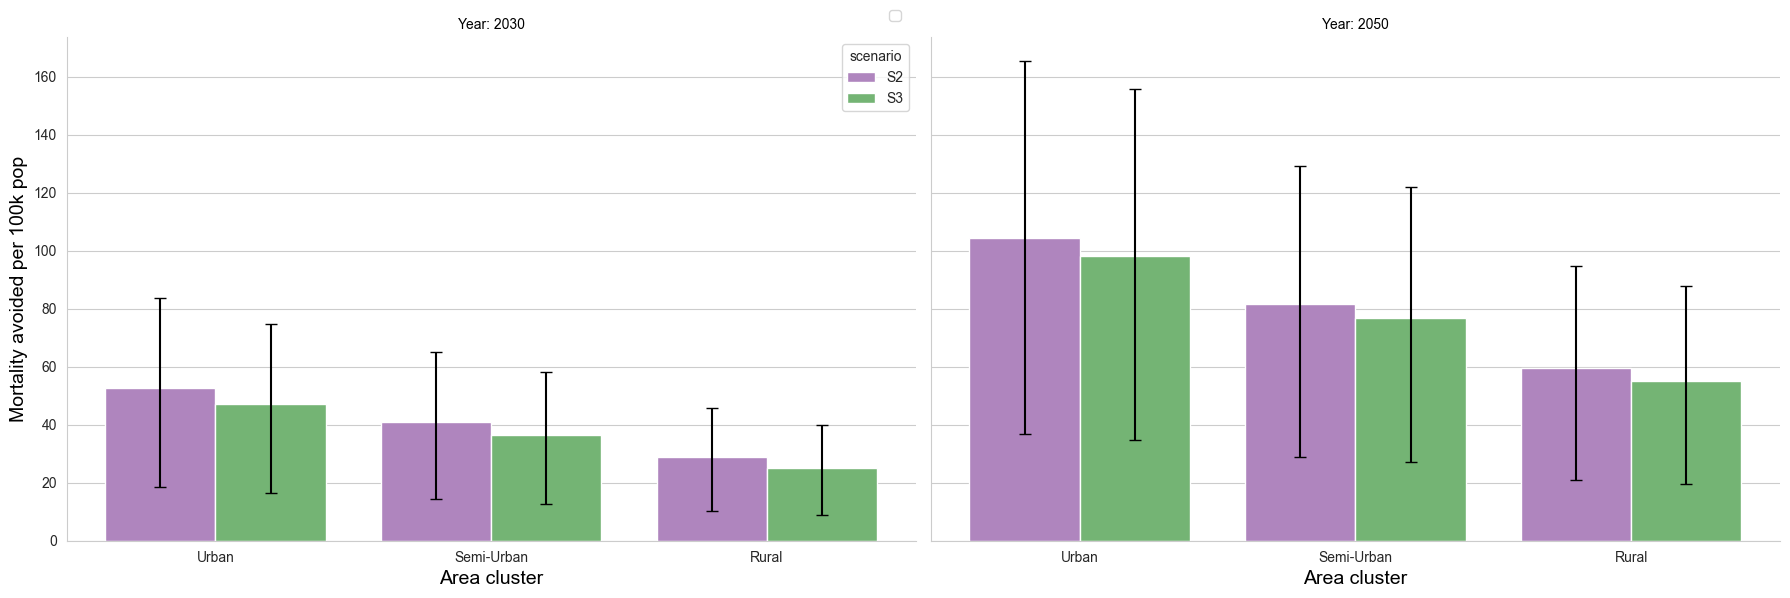

C:\Users\aysharma\AppData\Local\Temp\ipykernel_20412\743264058.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


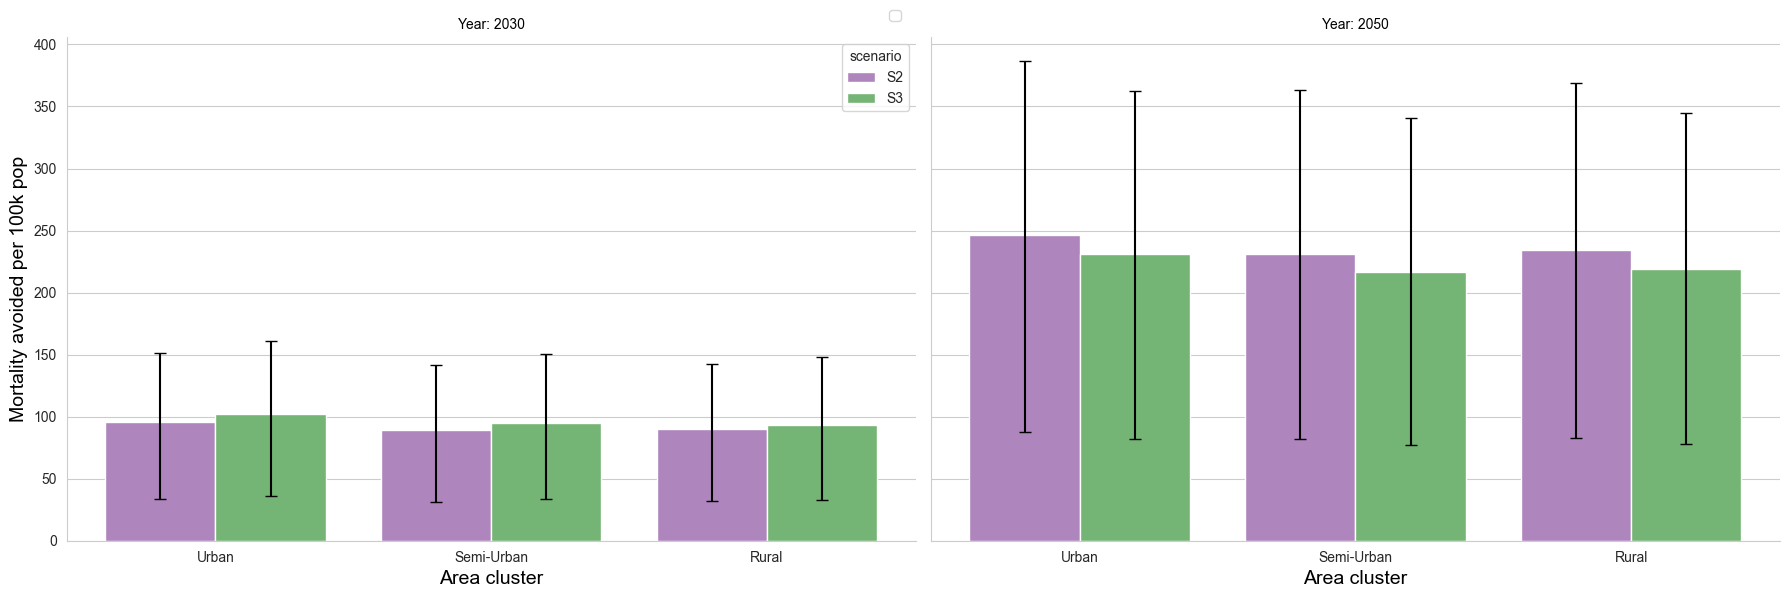

In [3]:
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import logging
import numpy as np
import os

# Scenario and area cluster visualization settings
scenario_colors = {
    "S2": "#B47CC7",
    "S3": "#6ABF69"
}
cluster_order = ["Urban", "Semi-Urban", "Rural"]


# Function to plot mortality avoided
def plot_pollutant(data, pollutant, output_dir, scenario_colors, cluster_order):
    """
    Plots mortality avoided for a given pollutant with annotations for percentage contributions
    and per-capita values.
    """
    try:
        # Filter data for the given pollutant
        pollutant_df = data[data["pollutant"] == pollutant].copy()

        # Check if the input dataframe is empty
        if pollutant_df.empty:
            logging.warning(f"No data available for pollutant '{pollutant}'. Skipping plot.")
            return

        # Verify required columns are present
        required_columns = ["area_cluster", "scenario", "year", "mortpol_age", "pop_age"]
        missing_columns = [col for col in required_columns if col not in pollutant_df.columns]
        if missing_columns:
            raise KeyError(f"Missing required columns for plotting: {missing_columns}")

        # Compute mortality avoided per 100k population dynamically
        pollutant_df["mortality_avoided_per_100k"] = np.where(
            pollutant_df["pop_age"] > 0,
            (pollutant_df["mortpol_age"] / pollutant_df["pop_age"]) * 100000,
            np.nan
        )

        # Compute national totals for percentage calculation
        national_totals = (
            pollutant_df.groupby(["scenario", "year", "pollutant"], as_index=False)
            .agg(national_avoid=("mortpol_age", "sum"))
        )

        # Merge national totals scoped by pollutant
        pollutant_df = pollutant_df.merge(national_totals, on=["scenario", "year", "pollutant"], how="left")

        # Calculate share of national benefit as percentage
        pollutant_df["share_national_pct"] = (
                pollutant_df["mortpol_age"] / pollutant_df["national_avoid"] * 100
        )

        # Bar plot using mortality per 100k population
        g = sns.catplot(
            data=pollutant_df,
            x="area_cluster",
            y="mortality_avoided_per_100k",
            hue="scenario",
            col="year",
            kind="bar",
            order=cluster_order,
            dodge=True,
            palette=scenario_colors,
            height=6,
            aspect=1.5,
            legend_out=False,
            ci=None  # Disable built-in confidence intervals
        )

        g.set_axis_labels("Area cluster", "Mortality avoided per 100k pop", fontsize=14, color="black")
        g.set_titles("Year: {col_name}", fontsize=14, color="black")
        g.fig.subplots_adjust(top=0.85)  # Adjust for legend placement

        # Add error bars and text annotations
        hue_order = list(scenario_colors.keys())
        bar_offsets = np.linspace(-0.2, 0.2, len(hue_order))

        for ax, year_val in zip(g.axes.flat, g.col_names):
            sub = pollutant_df[pollutant_df["year"] == year_val]
            for i, cluster in enumerate(cluster_order):
                for j, scenario in enumerate(hue_order):
                    row = sub[
                        (sub["area_cluster"] == cluster) &
                        (sub["scenario"] == scenario)
                        ]
                    if row.empty:
                        continue

                    height = row["mortality_avoided_per_100k"].values[0]  # Mortality per 100k
                    pct = row["share_national_pct"].values[0]  # Contribution to national mortality reductions

                    # Error bars for per 100k
                    lci_abs = row.get("mortpol_age_LCI", pd.Series([np.nan])).values[0]
                    uci_abs = row.get("mortpol_age_UCI", pd.Series([np.nan])).values[0]
                    pop = row["pop_age"].values[0]

                    lci = (lci_abs / pop) * 100000 if pd.notna(lci_abs) and pop > 0 else np.nan
                    uci = (uci_abs / pop) * 100000 if pd.notna(uci_abs) and pop > 0 else np.nan

                    x = i + bar_offsets[j]

                    # Add error bars if LCI and UCI are available
                    if pd.notna(lci) and pd.notna(uci):
                        ax.errorbar(
                            x=x,
                            y=height,
                            yerr=[[max(0, height - lci)], [uci - height]],
                            fmt="none",
                            ecolor="black",
                            capsize=4,
                            capthick=1,
                            zorder=10
                        )

                    # Add text annotation with only % contribution
                    #ax.text(
                        #x,
                        #height + (height * 0.60),
                        #f"{pct:.1f}%",
                        #ha="center",
                        #va="bottom",
                        #fontsize=12,
                        #color="black"
                    #)

        # Format axes
        for ax in g.axes.flat:
            ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

        # Add a single legend at the top for both plots
        handles, labels = next(iter(g.axes.flat)).get_legend_handles_labels()
        g.fig.legend(
            handles,
            labels,
            loc="upper center",
            ncol=len(scenario_colors),
            frameon=True,
            bbox_to_anchor=(0.5, 1.0)
        )

        plt.tight_layout()

        # Save plot
        filename = f"mortality_avoided_per_100k_by_area_cluster_{pollutant}.png"
        output_file = os.path.join(output_dir, filename)
        plt.savefig(output_file, dpi=300, bbox_inches="tight")
        logging.info(f"Plot saved for pollutant '{pollutant}' to {output_file}")
        plt.show()

    except KeyError as e:
        print(f"KeyError: {e}")
    except Exception as e:
        print(f"Error while plotting: {e}")


# Example Usage
output_dir = "data/2-output-data"
hia_results_df = pd.read_excel("data/2-output-data/hia_results_by_area_cluster_and_pollutant.xlsx")
pollutants_to_plot = ["ug_NO2", "ug_PM25_RH50"]
for pollutant in pollutants_to_plot:
    plot_pollutant(hia_results_df, pollutant, output_dir, scenario_colors, cluster_order)